# Study of Factors Behind Video Game Sales Success

We need to analyze data for the online store "Streamchik", which sells computer games worldwide.
The data covers sales through 2016. Using the historical record, we need to identify the patterns that determine whether a game succeeds, so that we can plan campaigns for 2017 and spot promising products.

### Open the data file and review the general information

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('/datasets/games.csv')

In [3]:
data.head(30)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [5]:
data.isna().sum()

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
NA_sales              0
EU_sales              0
JP_sales              0
Other_sales           0
Critic_Score       8578
User_Score         6701
Rating             6766
dtype: int64

### Data preprocessing

In [6]:
# convert column names to lowercase

data.columns = data.columns.str.lower()
data.head(30)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


In [7]:
# drop missing values in the release-year column

data = data.dropna(subset = ['year_of_release'])

There is no reasonable way to fill in the missing values in `['year_of_release']`, since each value is unique to its row. There are only 269 missing values in total, so dropping them will not meaningfully affect the overall picture.

In [8]:
data['year_of_release'].isna().sum()

0

In [9]:
# convert the release-year column to an integer type, since a year is always a whole number

data['year_of_release'] = data['year_of_release'].astype('int')

In [10]:
# check for anomalies

data['year_of_release'].unique()

array([2006, 1985, 2008, 2009, 1996, 1989, 1984, 2005, 1999, 2007, 2010,
       2013, 2004, 1990, 1988, 2002, 2001, 2011, 1998, 2015, 2012, 2014,
       1992, 1997, 1993, 1994, 1982, 2016, 2003, 1986, 2000, 1995, 1991,
       1981, 1987, 1980, 1983])

In [11]:
# drop missing values in the game-name column

data = data.dropna(subset = ['name'])

There is no reasonable way to fill in the missing values in `['name']`, since each value is unique. Dropping the 2 missing rows will not meaningfully affect the overall picture.

In [12]:
# drop missing values in the genre column

data = data.dropna(subset = ['genre'])

There is no reasonable way to fill in the missing values in `['genre']`, since each value is unique. Dropping the 2 missing rows will not meaningfully affect the overall picture.

In [13]:
# check the remaining missing values

data.isna().sum()

name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8461
user_score         6605
rating             6676
dtype: int64

In [14]:
# it is impossible to determine the missing values in the user-rating column, so we set a placeholder and keep that in mind going forward

data['user_score'] = data['user_score'].fillna(-1)

In [15]:
# check for anomalous values

data['user_score'].unique()

array(['8', -1, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

An anomalous value, `tbd`, was found in the numeric column — most likely short for "to be determined", meaning the rating isn't known yet.

In [16]:
# replace the string 'tbd' with None so we can change the column's data type

def tbd_score(raw):
    if raw['user_score'] == 'tbd':
        raw['user_score'] = None
    return raw
data = data.apply(tbd_score, axis = 1)

In [17]:
# convert the user-rating column from string to float

data['user_score'] = data['user_score'].astype('float64')

In [18]:
# it is impossible to determine the missing values in the critic-rating column, so we set a placeholder and keep that in mind going forward

data['critic_score'] = data['critic_score'].fillna(-1)

In [19]:
data.isna().sum()

name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score          0
user_score         2376
rating             6676
dtype: int64

In [20]:
# convert the critic-rating column from string to float

data['critic_score'] = data['critic_score'].astype('float')

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16444 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  int64  
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     16444 non-null  float64
 9   user_score       14068 non-null  float64
 10  rating           9768 non-null   object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.5+ MB


In [22]:
# check anomalous values in the ESRB rating column

data['rating'].unique()

array(['E', nan, 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP'], dtype=object)

It's hard to determine how the ESRB rating was assigned, so the missing values will be left as they are.

In [23]:
# check the data for duplicates

data.duplicated().sum()

0

In [24]:
# check the data for implicit duplicates

data[data[['name', 'platform','year_of_release']].duplicated(keep=False)]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
604,Madden NFL 13,PS3,2012,Sports,2.11,0.22,0.0,0.23,83.0,5.5,E
16230,Madden NFL 13,PS3,2012,Sports,0.00,0.01,0.0,0.00,83.0,5.5,E


One duplicate was found — the sales figures were evidently entered twice. We should keep the first row and drop the second.

In [25]:
# drop the implicit duplicate

data.drop_duplicates(subset=['name', 'platform', 'year_of_release'], keep='first', inplace=True)

In [26]:
# calculate total sales across all regions and record them in a separate column

data['total_sales'] = data['na_sales'] + data['eu_sales'] + data['jp_sales'] + data['other_sales']

In [27]:
data.head(20)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,-1.0,-1.0,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,-1.0,-1.0,NaN,31.38
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,-1.0,-1.0,NaN,30.26
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E,29.80
7,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E,28.91
8,New Super Mario Bros. Wii,Wii,2009,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E,28.32
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,-1.0,-1.0,NaN,28.31


We preprocessed the raw data: converted column names to lowercase. In `['year_of_release']` we dropped 269 missing values, since no reasonable replacement existed and removing them would not meaningfully affect the overall picture. We also dropped 2 rows each with missing values in `['name']` and `['genre']`. The columns `['critic_score']`, `['rating']`, and `['user_score']` had numerous missing values that could not be replaced with artificial data and could not be dropped either. To simplify the work, we replaced the missing values in `data['critic_score']` and `data['user_score']` with placeholders. We also found a unique string value, `tbd`, in `data['user_score']`, which we interpreted as "to be determined" and replaced with a placeholder so the column's type could later be changed from string to float. We checked the data for implicit duplicates and found one, which we removed. Finally, we calculated total sales across all regions and stored them in a separate column.

### Exploratory data analysis

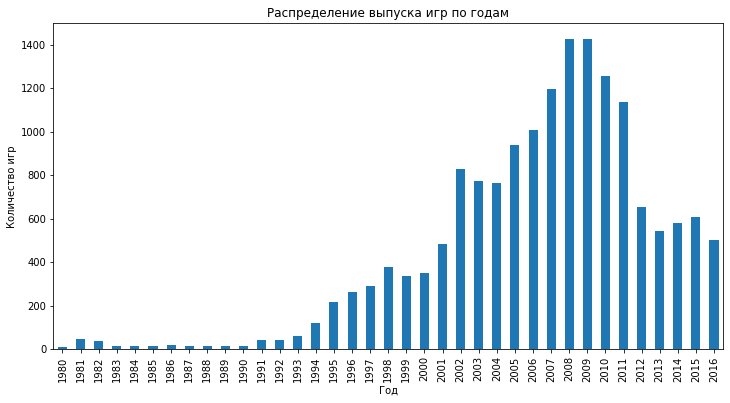

In [28]:
# let's see how many games were released by year

games_per_years = data['year_of_release'].value_counts().sort_index()

plt.figure(figsize=(12,6))
games_per_years.plot.bar()

plt.xlabel('Year')

plt.ylabel('Number of games')

plt.title('Distribution of game releases by year')
plt.show()

The chart shows that the data spans a long period, from 1980 to 2016. Game releases peaked in 2008-2009, then began to decline. The last three years show fairly similar figures. It makes sense to work with only that recent window in order to get an objective picture of the game market.

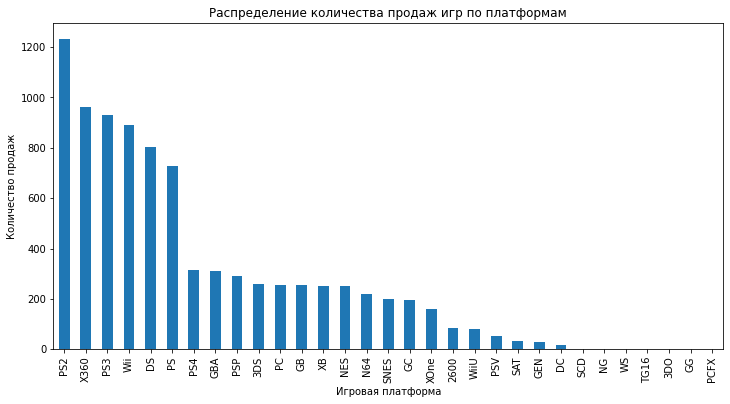

In [29]:
# let's see how sales changed by platform

sales_per_platform = data.groupby('platform')['total_sales'].sum()
sorted_platforms = sales_per_platform.sort_values(ascending = False)

plt.figure(figsize=(12,6))
sorted_platforms.plot.bar()

plt.xlabel('Gaming platform')

plt.ylabel('Number of sales')

plt.title('Distribution of game sales by platform')
plt.show()

The chart shows that the best-selling platforms overall are PS2, X360, and PS3.

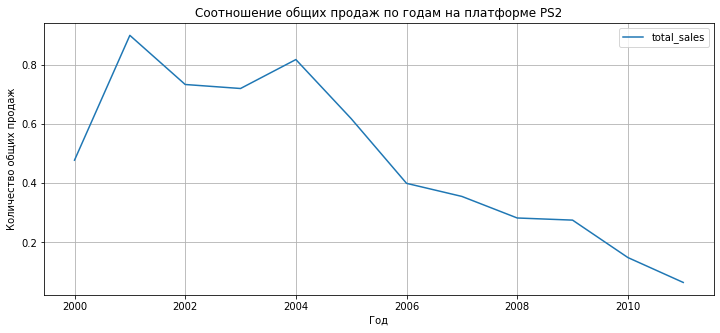

In [30]:
# take the most popular platform, PS2, and look at sales by year

ps2 = data.query('platform == "PS2"')
ps2_total_years = ps2.pivot_table(index = ['year_of_release'], values = 'total_sales', aggfunc = 'mean')

ps2_total_years.plot(grid =True, figsize =(12, 5), title = 'Total sales by year on the PS2 platform')
plt.xlabel('Year')
plt.ylabel('Total sales')
plt.show()

The chart shows that PS2 sales peaked in 2001, then started to decline, with the latest sales data going up to 2010. As a new console appears, the previous model's popularity falls, and its data is no longer relevant to the present moment.

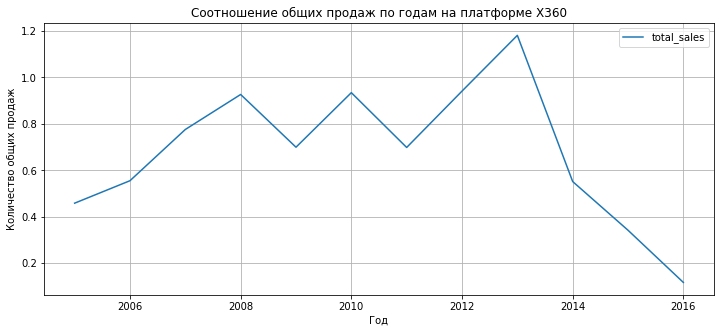

In [31]:
# take the second most popular platform, X360, and look at sales by year

x360 = data.query('platform == "X360"')
x360_total_years = x360.pivot_table(index = ['year_of_release'], values = 'total_sales', aggfunc = 'mean')

x360_total_years.plot(grid =True, figsize =(12, 5), title = 'Total sales by year on the X360 platform')
plt.xlabel('Year')
plt.ylabel('Total sales')
plt.show()

A very similar picture to PS2: sales peaked in 2013, then fell off sharply, to the point that 2016 sales are lower than they were when the console launched. This is because 2013 saw the launch of the new XOne model, which captured buyers' attention.

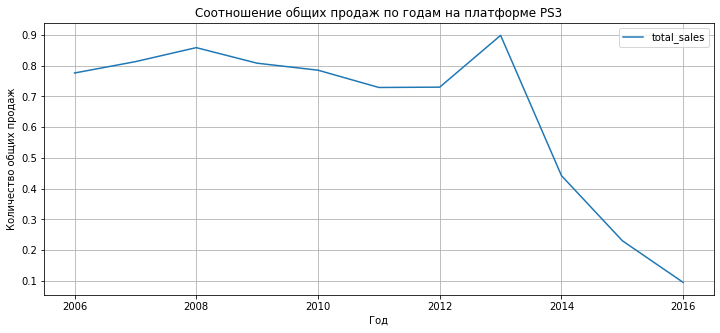

In [32]:
# take the third most popular platform, PS3, and look at sales by year

PS3 = data.query('platform == "PS3"')
PS3_total_years = PS3.pivot_table(index = ['year_of_release'], values = 'total_sales', aggfunc = 'mean')

PS3_total_years.plot(grid =True, figsize =(12, 5), title = 'Total sales by year on the PS3 platform')
plt.xlabel('Year')
plt.ylabel('Total sales')
plt.show()

While PS2 launched in 2000, PS3 came out 6 years later. Sales peaked in 2013 and then declined, so that 2016 sales are lower than in the console's launch year. This suggests a new model has most likely entered the market and will reach similar sales volumes in the near future.

In [33]:
# take the data for the current/relevant period starting in 2014 and identify potentially profitable platforms

data_2014 = data[data['year_of_release'] >= 2014]
data_pivot = data_2014.pivot_table(index = ['platform'], columns = 'year_of_release', values = 'total_sales', aggfunc = 'sum')

display(data_pivot)

year_of_release,2014,2015,2016
platform,,,
3DS,43.76,27.78,15.14
PC,13.28,8.52,5.25
PS3,47.76,16.82,3.60
PS4,100.00,118.90,69.25
PSP,0.24,0.12,NaN
PSV,11.90,6.25,4.25
Wii,3.75,1.14,0.18
WiiU,22.03,16.35,4.60
X360,34.74,11.96,1.52


We know that 2016 has incomplete data, so it's worth looking at the difference in sales between 2014 and 2015. The table shows that PS4 has the highest sales, and its 2015 sales grew compared to 2014. The same is true for the XOne console — it ranks second by sales and its sales are growing. Every other platform shows a decline in sales in 2015 compared to 2014.

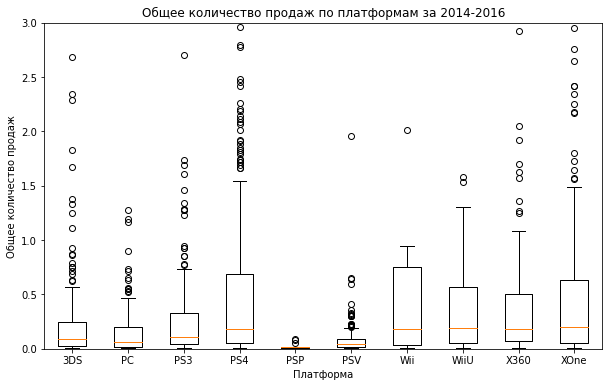

In [34]:
# build a box plot of global game sales broken down by platform

platforms = list(data_pivot.index)

plt.figure(figsize =(10,6))

# build a list of total sales data for each platform
sales_data = [list(data_2014[data_2014['platform'] == platform]['total_sales']) for platform in platforms]

# create the box plot
plt.boxplot(sales_data, labels=platforms)

# add labels
plt.xlabel('Platform')
plt.ylabel('Total sales')
plt.title('Total game sales by platform, 2014-2016')
plt.ylim([0, 3])

# display the box plot
plt.show()

The box plot lets us see sales volumes across different platforms. PS4, Wii, WiiU, X360, and XOne have almost identical median sales figures. PS4 has the widest spread of sales among the platforms. We also need to take the outliers visible on the chart into account — they can be read as especially popular games on a given platform.

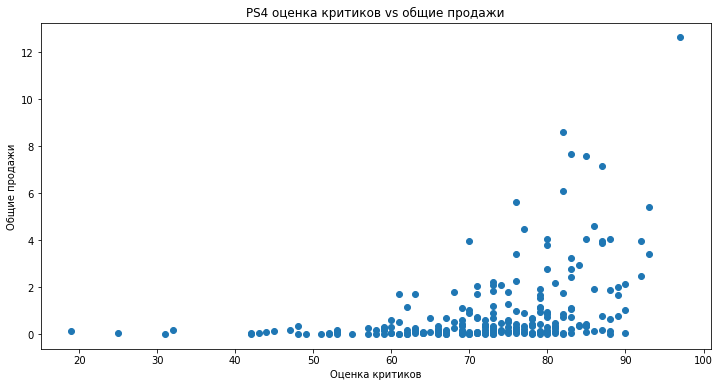

In [35]:
# let's see how critic and user reviews affect PS4 sales
# start with critic reviews

critic_PS4 =  data[(data['critic_score'] >= 0) & (data['platform'] == 'PS4') & (data['year_of_release'] >= 2014)]

plt.figure(figsize =(12,6))
critic_pivot = critic_PS4.pivot_table(index = ['platform'], columns = 'critic_score', values = 'total_sales', aggfunc = 'sum')

plt.scatter(critic_PS4['critic_score'], critic_PS4['total_sales'])

# set the axis and chart titles
plt.title('PS4 critic score vs. total sales')
plt.xlabel('Critic score')
plt.ylabel('Total sales')

plt.show()

In [36]:
# calculate the correlation between critic reviews and PS4 sales

critic_PS4['total_sales'].corr(critic_PS4['critic_score'])

0.40266141068104083

The scatter plot confirms there is a correlation between critic reviews and PS4 console sales.

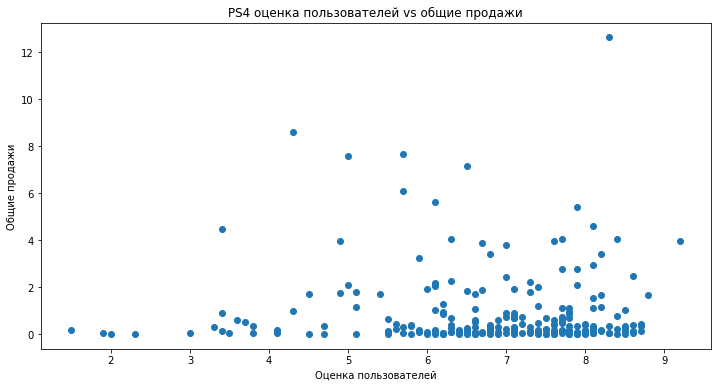

In [37]:
# let's see how user reviews affect PS4 sales

user_PS4 =  data[(data['user_score'] >= 0) & (data['user_score'] != None) & (data['platform'] == 'PS4') & (data['year_of_release'] >= 2014)]

plt.figure(figsize =(12,6))
user_pivot = user_PS4.pivot_table(index = ['platform'], columns = 'user_score', values = 'total_sales', aggfunc = 'sum')

plt.scatter(user_PS4['user_score'], user_PS4['total_sales'])

# set the axis and chart titles
plt.title('PS4 user score vs. total sales')
plt.xlabel('User score')
plt.ylabel('Total sales')

plt.show()

In [38]:
user_PS4['user_score'].corr(user_PS4['total_sales'])

-0.040131589472697356

The scatter plot indicates that the user score has no effect on sales volume. The chart shows games with a low rating that outsell some games with a high user rating.

In [39]:
# relate these findings to game sales on other platforms
# to do this, categorize platforms into the most popular ones and "other"

data['category_platform'] = data.apply(lambda row: 'PS4' if row['platform'] == 'PS4' 
                              else 'XOne' if row['platform'] == 'XOne'
                              else 'other', axis=1)

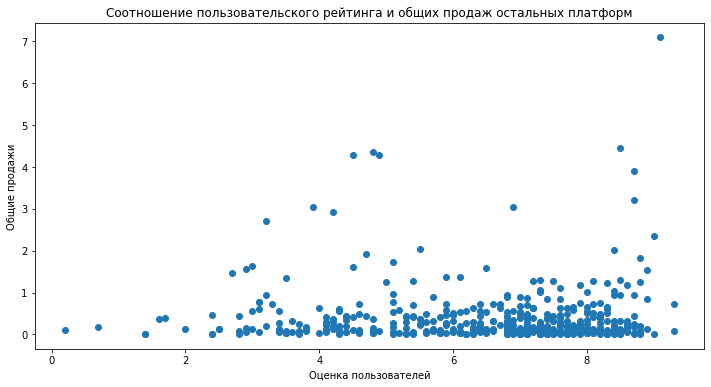

In [40]:
# build a sample of user ratings and sales for the other platforms

user_other =  data[(data['user_score'] >= 0) & (data['user_score'] != None) & (data['category_platform'] == 'other') & (data['year_of_release'] >= 2014)]

plt.figure(figsize =(12,6))
user_other_pivot = user_other.pivot_table(index = ['platform'], columns = 'user_score', values = 'total_sales', aggfunc = 'sum')

plt.scatter(user_other['user_score'], user_other['total_sales'])

plt.title('User score vs. total sales for the other platforms')
plt.xlabel('User score')
plt.ylabel('Total sales')

plt.show()

In [41]:
# determine the correlation coefficient

user_other['user_score'].corr(user_other['total_sales'])

-0.010564349095476886

The scatter plot and correlation coefficient show that, on other platforms too, there is no relationship between the user score and sales.

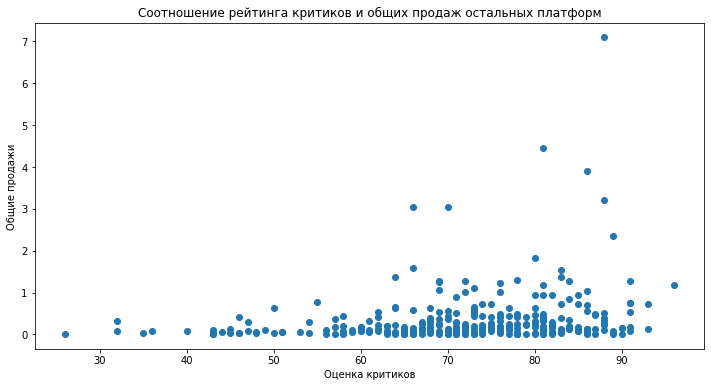

In [42]:
# build a sample of critic ratings and sales for the other platforms

critic_other =  data[(data['critic_score'] >= 0) & (data['category_platform'] == 'other') & (data['year_of_release'] >= 2014)]

plt.figure(figsize =(12,6))
critic_other_pivot = critic_other.pivot_table(index = ['platform'], columns = 'critic_score', values = 'total_sales', aggfunc = 'sum')

plt.scatter(critic_other['critic_score'], critic_other['total_sales'])

plt.title('Critic score vs. total sales for the other platforms')
plt.xlabel('Critic score')
plt.ylabel('Total sales')

plt.show()

In [43]:
critic_other['total_sales'].corr(critic_other['critic_score'])

0.21581043697880609

The scatter plot and correlation coefficient confirm that on the other platforms there is also a small relationship between critic reviews and total sales.

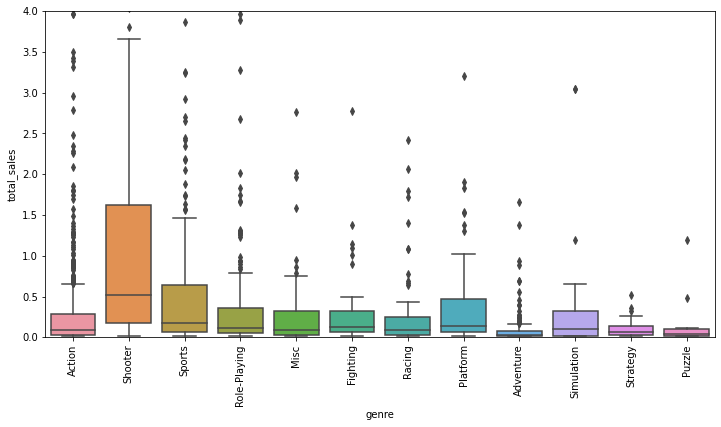

In [44]:
import seaborn as sns

plt.figure(figsize=(12,6))

# let's look at the overall distribution of game sales by genre

sales_per_genre = data_2014.groupby('genre')['total_sales'].sum()

# sort genres by total sales
sorted_genres = sales_per_genre.sort_values(ascending=False)

# build a list of genres in descending order of sales
genre_order = sorted_genres.index.tolist()

# build a box plot for each distribution
sns.boxplot(x='genre', y='total_sales', data=data_2014, order=genre_order)
plt.xticks(rotation=90)
plt.ylim([0, 4])
plt.show()

The most popular genre is Shooter, which has both the highest median sales and the widest spread. The least profitable genre is Puzzle. It's also worth noting the Action genre, which has many outlying values, pointing to a large number of smaller games with low sales.

### Build a user profile for each region

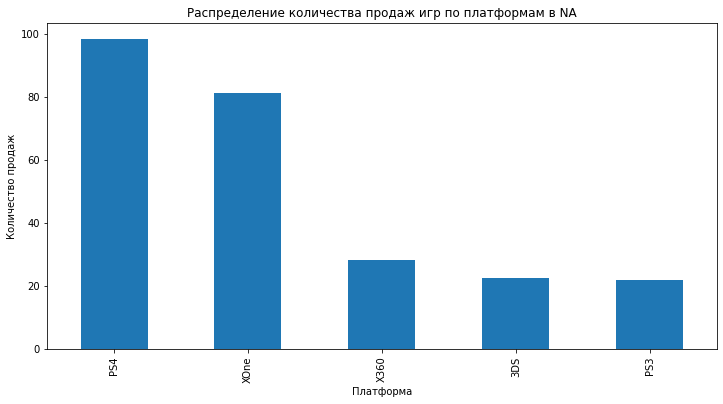

In [45]:
# determine the top 5 popular platforms for the North America region

na_sales = data_2014.groupby('platform')['na_sales'].sum()
sorted_na_sales_platform = na_sales.sort_values(ascending = False)[:5]

plt.figure(figsize=(12,6))
sorted_na_sales_platform.plot.bar()

plt.xlabel('Platform')

plt.ylabel('Number of sales')

plt.title('Distribution of game sales by platform in NA')
plt.show()

The bulk of North American sales go to platforms like PS4 — about 100 million sales — followed in popularity by the XOne console with 80 million sales. The remaining three platforms, X360, 3DS, and PS3, have almost equal shares of around 20 million sales each, five times less than PS4. Accordingly, they are the least popular among North American buyers.

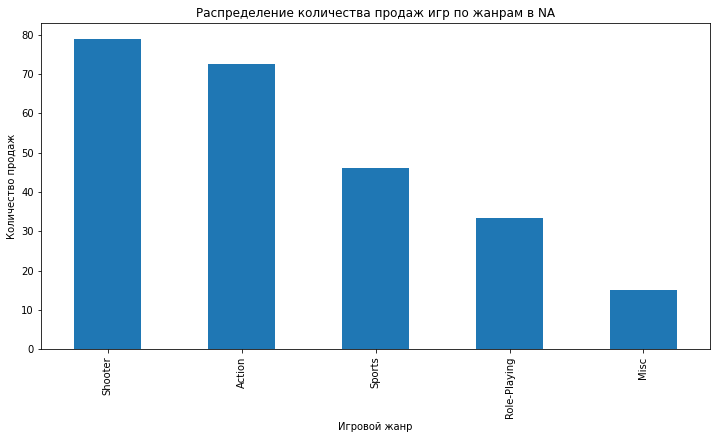

In [46]:
# determine the top 5 popular game genres for the North America region

na_sales = data_2014.groupby('genre')['na_sales'].sum()
sorted_na_sales_genre = na_sales.sort_values(ascending = False)[:5]

plt.figure(figsize=(12,6))
sorted_na_sales_genre.plot.bar()

plt.xlabel('Genre')

plt.ylabel('Number of sales')

plt.title('Distribution of game sales by genre in NA')
plt.show()

The most popular genre in North America is Shooter, with 80 million sales; Action takes second place with 75 million sales, followed by Sports, Role-Playing, and Misc rounding out the top five. Sports accounts for 45 million sales, almost half of the top genre, Shooter. Misc, in turn, is the least popular genre with just 15 million sales.

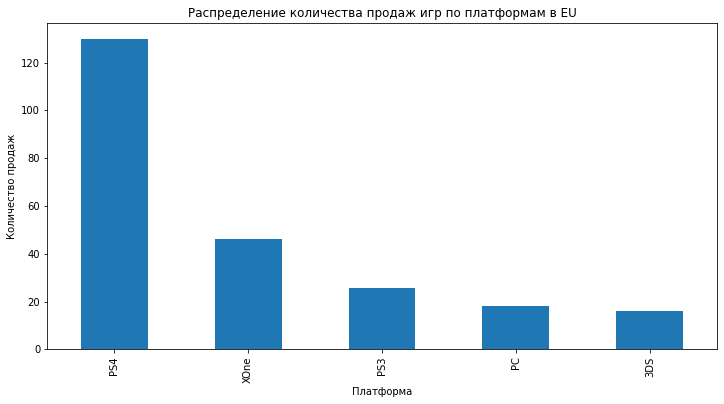

In [47]:
# determine the top 5 popular platforms for the Europe region

eu_sales = data_2014.groupby('platform')['eu_sales'].sum()
sorted_eu_sales_platform = eu_sales.sort_values(ascending = False)[:5]

plt.figure(figsize=(12,6))
sorted_eu_sales_platform.plot.bar()

plt.xlabel('Platform')

plt.ylabel('Number of sales')

plt.title('Distribution of game sales by platform in EU')
plt.show()

The most popular platform in Europe is PS4, accounting for more than 120 million sales, while the remaining top platforms trail far behind. The second most popular platform is XOne, but its sales total only 40 million — three times less than PS4. The other 4 platforms in the top 5 can be considered niche, as their share of sales is very small compared to PS4.

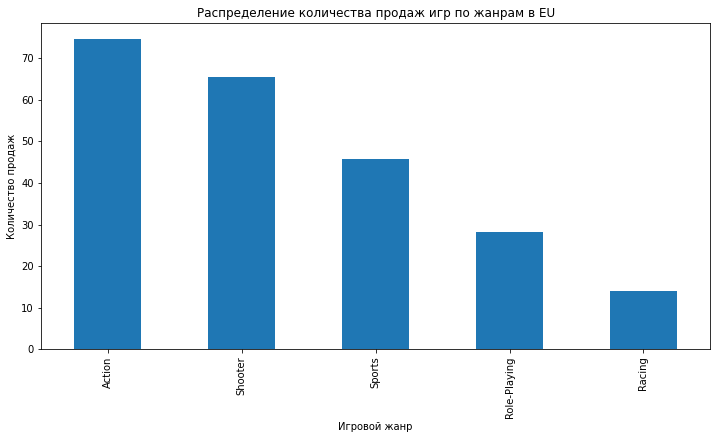

In [48]:
# determine the top 5 popular game genres for the Europe region

eu_sales = data_2014.groupby('genre')['eu_sales'].sum()
sorted_eu_sales_genre = eu_sales.sort_values(ascending = False)[:5]

plt.figure(figsize=(12,6))
sorted_eu_sales_genre.plot.bar()

plt.xlabel('Genre')

plt.ylabel('Number of sales')

plt.title('Distribution of game sales by genre in EU')
plt.show()

Unlike North America, in Europe the most popular game genre is Action, accounting for 70 million sales. Second place goes to Shooter with 65 million sales. The third most popular genre is Sports with 45 million sales. Role-Playing has 30 million sales, almost 2.5 times less than the top genre, Action. Racing takes 5th place with 15 million sales.

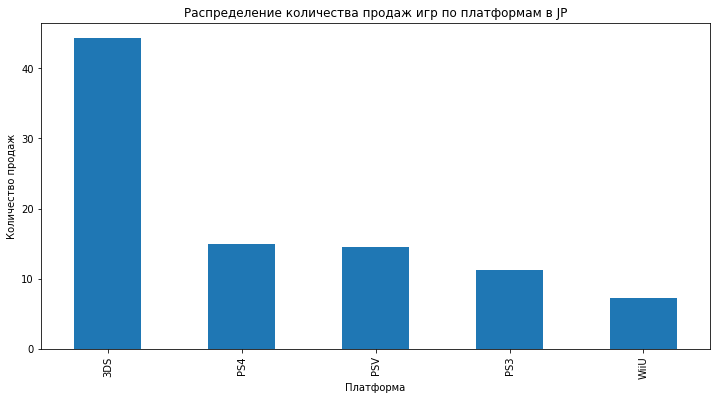

In [49]:
# determine the top 5 popular platforms for the Japan region

jp_sales = data_2014.groupby('platform')['jp_sales'].sum()
sorted_jp_sales_platform = jp_sales.sort_values(ascending = False)[:5]

plt.figure(figsize=(12,6))
sorted_jp_sales_platform.plot.bar()

plt.xlabel('Platform')

plt.ylabel('Number of sales')

plt.title('Distribution of game sales by platform in JP')
plt.show()

Unlike North America and Europe, where the top platform is PS4, in Japan that top spot belongs to the 3DS, with more than 40 million sales. The remaining platforms in the top 5 — PS4, PSV, PS3, WiiU — are far less popular, with shares three times smaller than the leading 3DS.

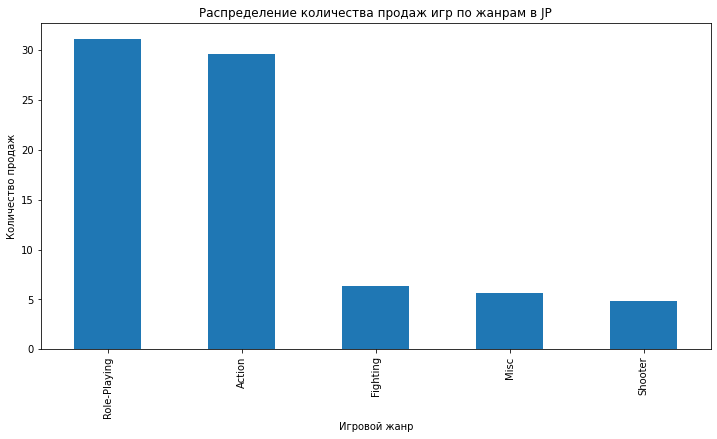

In [50]:
# determine the top 5 popular game genres for the Japan region

jp_sales = data_2014.groupby('genre')['jp_sales'].sum()
sorted_jp_sales_genre = jp_sales.sort_values(ascending = False)[:5]

plt.figure(figsize=(12,6))
sorted_jp_sales_genre.plot.bar()

plt.xlabel('Genre')

plt.ylabel('Number of sales')

plt.title('Distribution of game sales by genre in JP')
plt.show()

While Action and Shooter lead among North American and European buyers, in Japan the top spot belongs to Role-Playing, with 30 million sales. Action comes second, with almost 30 million sales as well. The remaining three genres in the top 5 — Fighting, Misc, Shooter — are far less significant, with a share six times smaller than the top two genres.

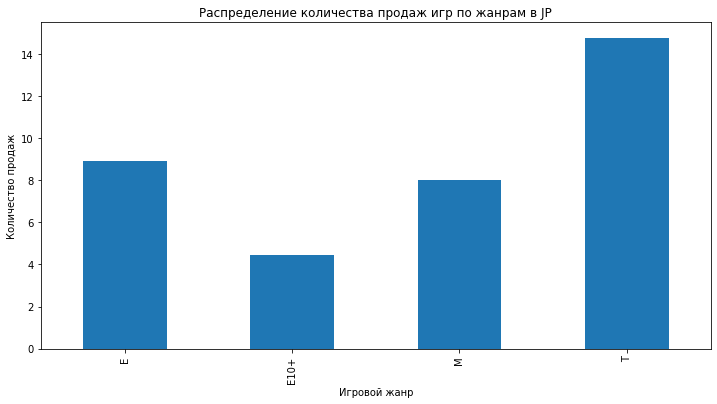

In [51]:
# does the ESRB rating affect sales in Japan?

esrb = data_2014.groupby('rating')['jp_sales'].sum()
plt.figure(figsize=(12,6))
esrb.plot.bar()

plt.xlabel('ESRB rating')

plt.ylabel('Number of sales')

plt.title('Distribution of game sales by ESRB rating in JP')
plt.show()

The chart shows that the ESRB rating definitely affects sales. In Japan, the best-selling games are those rated T, while games rated E10+ sell the least.

### Testing hypotheses

#### Let's state the null hypothesis H0: the average user ratings for the Xbox One and PC platforms are equal. The alternative hypothesis H1: the average user ratings for the Xbox One and PC platforms are not equal.

In [52]:
# take a slice of the current-period data for the XOne platform
xone = data_2014.query('platform == "XOne"')

# remove the rows where we substituted placeholder values for the user rating

xone_real = xone[(xone['user_score'] >= 0) & (xone['user_score'] != None)]

# extract the user-rating column for the XOne platform
xone_score = xone_real['user_score']             
xone_real_mean = xone_real['user_score'].mean()

In [53]:
# take a slice of the current-period data for the PC platform

pc = data_2014.query('platform == "PC"')

# remove the rows where we substituted placeholder values for the user rating

pc_real = pc[(pc['user_score'] >= 0) & (pc['user_score'] != None)]

# extract the user-rating column for the PC platform

pc_score = pc_real['user_score']
pc_real_mean = pc_real['user_score'].mean()

In [54]:
from scipy import stats as st

# to test whether the average user rating is the same for the Xbox One and
# PC platforms, we can run a two-sample t-test

t_stat, p_value = st.ttest_ind(xone_score, pc_score, equal_var=False)

if p_value < 0.05:
    print('We reject the null hypothesis that the user ratings of the XOne and PC platforms are equal')
else:
    print("We failed to reject the null hypothesis that the user ratings of the XOne and PC platforms are equal")

We failed to reject the null hypothesis that the user ratings of the XOne and PC platforms are equal


We stated the null and alternative hypotheses:
Null hypothesis (H0): the average user rating is the same for the Xbox One and PC platforms.
Alternative hypothesis (H1): the average user rating is not the same for the Xbox One and PC platforms.
We extracted the user ratings for the Xbox One and PC platforms from the dataset. We then used a two-sample t-test to determine whether the difference in means was statistically significant. The result showed that the p-value is greater than our chosen significance level (the standard value of 0.05), so we cannot reject the null hypothesis and cannot conclude that there is a significant difference between the average user ratings of the two platforms.

#### Let's test the next hypothesis: the average user ratings of the Action and Sports genres differ

#### Let's state the null hypothesis H0: the average user ratings of the Action and Sports genres are equal. The alternative hypothesis H1: the average user ratings of the Action and Sports genres are not equal.

In [55]:
# take a slice of the current-period data for the Action genre

action = data_2014.query('genre == "Action"')

# remove the rows where we substituted placeholder values for the user rating

action_real = action[(action['user_score'] >= 0) & (action['user_score'] != None)]

# extract the user-rating column for the Action genre

action_score = action_real['user_score']                 
action_real_mean = action_real['user_score'].mean()

In [56]:
# take a slice of the current-period data for the Sports genre

sports = data_2014.query('genre == "Sports"')

# remove the rows where we substituted placeholder values for the user rating

sports_real = sports[(sports['user_score'] >= 0) & (sports['user_score'] != None)]

# extract the user-rating column for the Sports genre

sports_score = sports_real['user_score']  

sports_real_mean = sports_real['user_score'].mean()

In [57]:
t_stat, p_value = st.ttest_ind(action_score, sports_score, equal_var=False)

if p_value < 0.05:
    print('We reject the null hypothesis that the user ratings of the Action and Sports genres are equal')
else:
    print('We failed to reject the null hypothesis that the user ratings of the Action and Sports genres are equal')

We reject the null hypothesis that the user ratings of the Action and Sports genres are equal


We stated the null and alternative hypotheses: Null hypothesis (H0): the average user ratings of the Action and Sports genres are equal. Alternative hypothesis (H1): the average user ratings of the Action and Sports genres are not equal. We extracted the user ratings for the Action and Sports genres from the dataset. We then used a two-sample t-test to determine whether the difference in means was statistically significant. The result showed that we can reject the null hypothesis — the two genres' ratings have different means.

### Conclusion

We analyzed sales data from the online store "Streamchik" for computer games sold worldwide. The dataset had numerous missing values in the user-rating, critic-rating, and ESRB age-rating columns. Since there is no way to replace these with realistic values, that limitation should be kept in mind when reading the conclusions below. We carried out exploratory analysis and determined that not all of the data is useful for forecasting future sales. Analyzing the number of games released by year showed that release volume varies a great deal across years, peaking in 2008-2009 before declining noticeably. The last three years in the data show fairly similar figures. We also looked at sales across all years by platform and found that the best-selling platforms overall are PS2, X360, and PS3. However, because platforms are continually replaced by new ones, sales on a given platform change depending on when a new model launches — new platforms tend to appear roughly every 5 years. To keep the data relevant, we restricted our analysis to games released from 2014 onward, since that gives a more realistic picture of the current market.

We found that PS4 has the highest sales worldwide, and its 2015 sales grew compared to 2014. The same is true of the XOne console, which ranks second by sales and continues to grow. Every other platform shows declining sales in 2015 versus 2014.
We also found a correlation between critic reviews and PS4 console sales, while the user score, by contrast, has no effect on sales volume. The same pattern holds on the other platforms.

The most popular genre is Shooter, with the highest total sales. The lowest-selling genre is Puzzle.

We built a user profile for each region.

The bulk of North American sales goes to platforms like PS4 (about 100 million sales), followed by the XOne console (80 million sales).
The most popular genre in North America is Shooter (80 million sales), with Action in second place (75 million sales).

The most popular platform in Europe is PS4, accounting for more than 120 million sales, while the other leading platforms trail far behind. The second most popular platform is XOne, with sales of only 40 million — three times less than PS4.
Unlike North America, the most popular genre in Europe is Action, with 70 million sales. Shooter takes second place with 65 million sales.

Unlike North America and Europe, where PS4 is the top platform, in Japan that spot belongs to the 3DS, with more than 40 million sales.
While Action and Shooter lead among North American and European buyers, in Japan the top genre is Role-Playing, with 30 million sales. Action comes second, with almost 30 million sales as well.

We examined how the age rating affects sales in Japan and found that sales do vary depending on the assigned rating.

We also tested two hypotheses:
The average user ratings of the Xbox One and PC platforms are equal — this hypothesis was supported.
The average user ratings of the Action and Sports genres are equal — this hypothesis was not supported.

To forecast a game's likely success, it is important to take into account the region where the game is released, as well as regional preferences for particular genres. The platform the game is released on also matters — above all, how relevant that platform still is for the given year and region.